In [ ]:
from PIL import Image, ImageFile
import math
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
card_w = 63
card_h = 88
margin = 3.175

In [41]:
def expand_for_bleed(image: ImageFile) -> Image:
    """ Based on the width and height of the image, expands
        the last row/column of pixels to create a bleed. Does
        this blindly so it assumes it has been preprocessed as much 
        as you want before this

    """
    width, height = image.size
    bleed_pixels_h = math.ceil(margin/card_h * height)
    bleed_pixels_w = math.ceil(margin/card_w * width)
    image_array = np.array(list(image.getdata())).reshape((height,width,-1))[:,:,:3]
    top_bleed = np.tile(image_array[0,...].ravel(),reps=bleed_pixels_w).reshape((bleed_pixels_w,width,3))
    bottom_bleed = np.tile(image_array[-1,...].ravel(),reps=bleed_pixels_w).reshape((bleed_pixels_w,width,3))
    image_array = np.concatenate((top_bleed, image_array, bottom_bleed))
    height = image_array.shape[0]
    left_bleed =  np.repeat(image_array[:,0,...], repeats=bleed_pixels_h, axis=0).reshape((height,bleed_pixels_h,3))
    right_bleed = np.repeat(image_array[:,-1,...],repeats=bleed_pixels_h, axis=0).reshape((height,bleed_pixels_h,3))
    image_array = np.concatenate((left_bleed, image_array, right_bleed),axis=1)
    img_w_bleed = Image.fromarray(np.uint8(image_array))
    return img_w_bleed

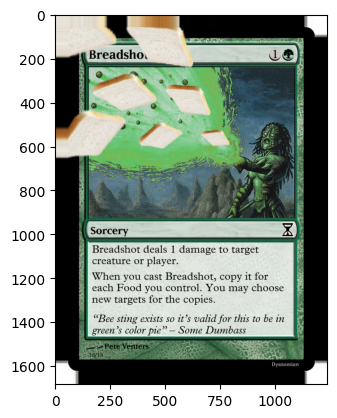

In [42]:
# image_path = (Path(os.path.abspath('')).parent / "downloads") / "draftable_upscaled/1_2_of_Elesh_Norn_Rounded_Up.png"
image_path = (Path(os.path.abspath('')).parent / "downloads") / "draftable_upscaled/Breadshot.png"
reference_border = Image.open(Path(os.path.abspath('')).parent / "MPCReference.png")
img = Image.open(image_path)
img_w_bleed = expand_for_bleed(img)
reference_border = reference_border.resize(img_w_bleed.size)
plt.imshow(img_w_bleed)
# plt.imshow(reference_border)
img_w_bleed.save("TestBleed.png")